|Dataset Name| Algorithm| Complated| Accuracy Score|
|   :---:    | :---:| :---: |:---:|
| Insurance Dataset|  Linear Regression | No | 74.24|

In [283]:
import pandas as pd

In [284]:
df = pd.read_csv('/Users/ahmetnuriyavuzkanat/Documents/Programming/AI/SupervisedMachineLearning/data/insurance.csv')

In [285]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [286]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [287]:
print(df['sex'].unique())

<StringArray>
['female', 'male']
Length: 2, dtype: str


In [288]:
print(df['region'].unique())
print(df['age'].unique())
print(df['children'].unique())

<StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str
[19 18 28 33 32 31 46 37 60 25 62 23 56 27 52 30 34 59 63 55 22 26 35 24
 41 38 36 21 48 40 58 53 43 64 20 61 44 57 29 45 54 49 47 51 42 50 39]
[0 1 3 2 5 4]


In [289]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [290]:
import seaborn as sns
import matplotlib.pyplot as plt


<Axes: xlabel='charges', ylabel='Count'>

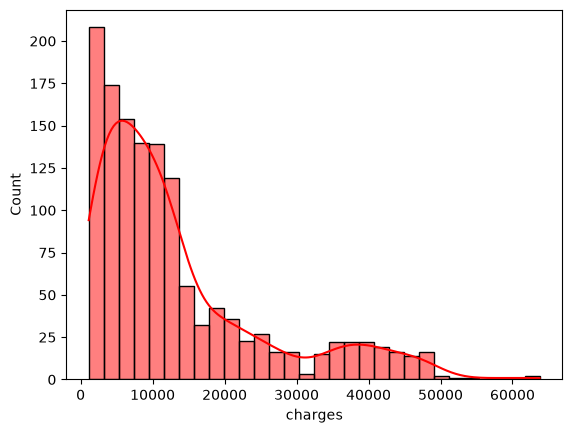

In [291]:
sns.histplot(data=df, x='charges', kde=True, color='red')

<Axes: xlabel='age', ylabel='Count'>

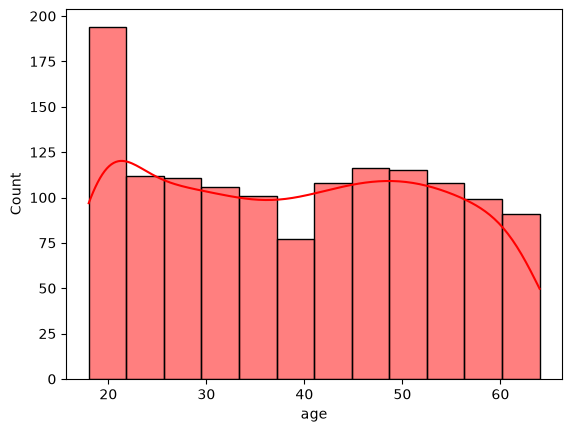

In [292]:
sns.histplot(data=df, x='age', kde=True, color='red')

In [293]:
numerical_cols = ['age', 'bmi', 'children', 'charges']
corr_matrix = df[numerical_cols].corr()['charges'].sort_values(ascending=False)
corr_matrix

charges     1.000000
age         0.299008
bmi         0.198341
children    0.067998
Name: charges, dtype: float64

In [294]:
df = pd.get_dummies(df,drop_first=True)
df

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,True,False,True,False,False
1334,18,31.920,0,2205.98080,False,False,False,False,False
1335,18,36.850,0,1629.83350,False,False,False,True,False
1336,21,25.800,0,2007.94500,False,False,False,False,True


In [295]:
df.corr().abs()['charges'].sort_values(ascending=False)

charges             1.000000
smoker_yes          0.787251
age                 0.299008
bmi                 0.198341
region_southeast    0.073982
children            0.067998
sex_male            0.057292
region_southwest    0.043210
region_northwest    0.039905
Name: charges, dtype: float64

In [296]:
X = df[['smoker_yes','age','bmi','region_southeast','children','sex_male','region_southwest','region_northwest']]

y = df.charges

In [297]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.3)

In [298]:
from sklearn.linear_model import LinearRegression

LR = LinearRegression()

LR.fit(X_train,y_train)

print(f" Linear Regression Train Score : {LR.score(X_train,y_train):.4f}")
print(f" Linear Regression Test Score : {LR.score(X_test,y_test):.4f}")

 Linear Regression Train Score : 0.7424
 Linear Regression Test Score : 0.7696


In [299]:
from sklearn.preprocessing import PolynomialFeatures


poly = PolynomialFeatures(degree=2,include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)


In [300]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_poly_scaled = scaler.fit_transform(X_train_poly)

X_test_poly_scaled = scaler.transform(X_test_poly)



In [301]:
LR2  = LinearRegression()

LR2.fit(X_train_poly_scaled,y_train)


print(f" Linear Regression Train Score : {LR2.score(X_train_poly_scaled,y_train):.4f}")
print(f" Linear Regression Test Score : {LR2.score(X_test_poly_scaled,y_test):.4f}")

 Linear Regression Train Score : 0.8401
 Linear Regression Test Score : 0.8606


In [302]:
from sklearn.linear_model import Ridge
import numpy as np 


test_scores = []
train_scores = []


alphas = np.linspace(0.0001,10,10)

for x in alphas:
        R = Ridge(alpha=x)
        R.fit(X_train_poly_scaled,y_train)
        test_scores.append(R.score(X_test_poly_scaled,y_test))
        train_scores.append(R.score(X_train_poly_scaled,y_train))

print("alpha    | test score | train score")        
for a,test,train in zip(alphas,test_scores,train_scores):
    print(f" {a:.4f}   |  {test:.4f}   | {train:.4f}")

alpha    | test score | train score
 0.0001   |  0.8606   | 0.8401
 1.1112   |  0.8605   | 0.8399
 2.2223   |  0.8601   | 0.8395
 3.3334   |  0.8594   | 0.8389
 4.4445   |  0.8586   | 0.8381
 5.5556   |  0.8577   | 0.8373
 6.6667   |  0.8568   | 0.8365
 7.7778   |  0.8558   | 0.8356
 8.8889   |  0.8547   | 0.8347
 10.0000   |  0.8537   | 0.8337
